### 合并行业数据

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"E:\大四科研\其他科研\一带一路_公司\data\BR_year.csv")
data.rename(columns = {'date':'year'}, inplace = True)

In [3]:
#####合并行业数据#####
industry = pd.read_csv(r"E:\大四科研\其他科研\一带一路_公司\data\industry.csv")
industry.rename(columns = {'Symbol':'asset'}, inplace = True)
industry['year'] = pd.to_datetime(industry['EndDate']).dt.year
industry.drop(columns = ['ListedCoID','EndDate'], inplace = True)
merged_data = pd.merge(data, industry, on = ['asset','year'], how = 'inner')
print(merged_data)

        asset  year  br_   br ShortName IndustryNameC IndustryCodeC
0           2  2014  0.0  0.0       万科A          房地产业           K70
1           2  2015  0.0  0.0       万科A          房地产业           K70
2           2  2016  0.0  0.0       万科A          房地产业           K70
3           2  2017  0.0  0.0       万科A          房地产业           K70
4           2  2018  0.0  0.0       万科A          房地产业           K70
...       ...   ...  ...  ...       ...           ...           ...
27702  873305  2020  0.0  0.0      九菱科技         金属制品业           C33
27703  873305  2021  0.0  0.0      九菱科技         金属制品业           C33
27704  873339  2019  0.0  0.0      恒太照明    电气机械及器材制造业           C38
27705  873339  2020  0.0  0.0      恒太照明    电气机械及器材制造业           C38
27706  873339  2021  0.0  0.0      恒太照明    电气机械及器材制造业           C38

[27707 rows x 7 columns]


In [4]:
merged_data.to_excel("E:/大四科研/其他科研/一带一路_公司/data/BR_industry_merged.xlsx", index = False)

### Summary Statistics

In [5]:
#####cross-sectional summary statistics#####
grouped = merged_data.groupby('year')['br_'].describe()
print(grouped)

       count      mean       std  min  25%  50%       75%       max
year                                                               
2014  2438.0  0.000007  0.000052  0.0  0.0  0.0  0.000000  0.002382
2015  2630.0  0.000010  0.000059  0.0  0.0  0.0  0.000011  0.002747
2016  3056.0  0.000010  0.000051  0.0  0.0  0.0  0.000011  0.002486
2017  3436.0  0.000011  0.000052  0.0  0.0  0.0  0.000012  0.002659
2018  3535.0  0.000010  0.000048  0.0  0.0  0.0  0.000011  0.002565
2019  3748.0  0.000008  0.000045  0.0  0.0  0.0  0.000009  0.002444
2020  4214.0  0.000006  0.000050  0.0  0.0  0.0  0.000000  0.002995
2021  4650.0  0.000006  0.000054  0.0  0.0  0.0  0.000000  0.003493


In [6]:
#####time-series average#####
summary_statistics = grouped.mean()
print(summary_statistics)

count    3463.375000
mean        0.000008
std         0.000051
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000007
max         0.002722
dtype: float64


#### 计算提及一带一路的比例

In [7]:
#####提及一带一路的年报数的比例#####
br_mentioned = merged_data['br_'].ne(0).sum()
br_total = merged_data['br_'].count()
br_ratio = br_mentioned / br_total
print(br_ratio)

#####提及一带一路的公司数比例#####
br_mentioned_comp = merged_data.loc[merged_data['br_'].ne(0), 'asset'].nunique()
br_total_comp = merged_data['asset'].nunique()
br_ratio_comp = br_mentioned_comp / br_total_comp
print(br_ratio_comp)

0.274912476991374
0.5109677419354839


### 计算行业BR均值

In [14]:
merged_data['Industry'] = merged_data['IndustryCodeC'].apply(lambda x:x[0])
annual_averages = merged_data.groupby(['Industry','year'])['br_'].mean().reset_index()
print(annual_averages)

    Industry  year       br_
0          A  2014  0.000003
1          A  2015  0.000004
2          A  2016  0.000008
3          A  2017  0.000007
4          A  2018  0.000006
..       ...   ...       ...
137        S  2017  0.000010
138        S  2018  0.000010
139        S  2019  0.000013
140        S  2020  0.000011
141        S  2021  0.000013

[142 rows x 3 columns]


In [15]:
industry_averages = annual_averages.groupby(['Industry'])['br_'].mean().reset_index()
sorted_industry_averages = industry_averages.sort_values(by = 'br_', ascending = False)
print(sorted_industry_averages)

   Industry       br_
4         E  0.000058
6         G  0.000023
18        S  0.000016
12        M  0.000016
17        R  0.000012
11        L  0.000011
1         B  0.000010
9         J  0.000008
2         C  0.000007
7         H  0.000007
0         A  0.000006
5         F  0.000006
13        N  0.000005
3         D  0.000005
8         I  0.000005
10        K  0.000005
16        Q  0.000002
15        P  0.000002
14        O  0.000000


In [16]:
sorted_industry_averages.to_excel(r"E:\大四科研\其他科研\一带一路_公司\data\industry_br_mean.xlsx", index = False)

### 做行业图

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
plot_data = pd.read_excel(r"E:\大四科研\其他科研\一带一路_公司\data\industry_br_mean.xlsx")

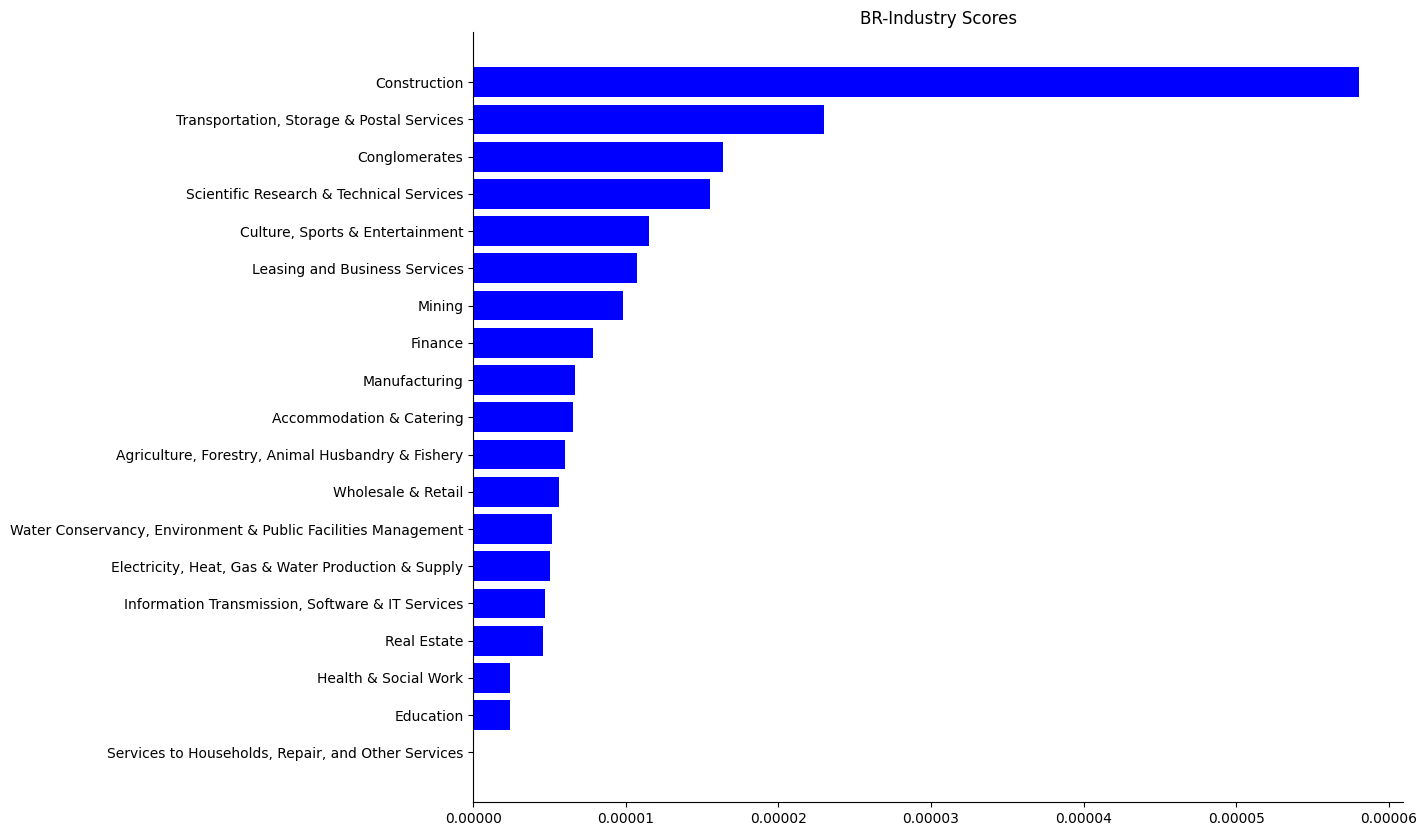

In [3]:
#####ploting#####
plt.figure(figsize=(12,10))
plt.barh(plot_data['Ind_name'], plot_data['br_'], color='blue')
plt.title('BR-Industry Scores')
plt.gca().invert_yaxis()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ticklabel_format(style='plain',axis='x')
plt.savefig('E:\大四科研\其他科研\一带一路_公司\data\industry_br_score.pdf',dpi=300, bbox_inches='tight')  # Save as PNG with high resolution
plt.show()